# Celltyping

We will demonstrate an example of the `sainsc` celltyping workflow using the Stereo-seq Mouse Embryo E16.5 (E1S3) from the original [Stereo-seq publication](https://www.sciencedirect.com/science/article/pii/S0092867422003993).

The Stereo-seq dataset used in this analysis is available at [https://db.cngb.org/stomics/mosta](https://db.cngb.org/stomics/mosta).

To follow along, make sure you installed `sainsc` with the 'data' extra (``pip install sainsc[data]``) and the `scanpy` (>=1.12), `squidpy`, and `colorcet` packages. Alternatively, install the 'tutorial' extra (``pip install sainsc[tutorial]``) to get all required dependencies.

First we need to load some essential packages and define the input file we are going to use.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sainsc.io import read_StereoSeq

# location of the Stereo-seq data
stereo_seq_file = Path("path/to/stereoseq_data") / "E16.5_E1S3_GEM_bin1.tsv.gz"

## Load and prepare data

First we are going to load the Stereo-seq data from the GEM file.

In [2]:
embryo = read_StereoSeq(stereo_seq_file)

print(embryo)

LazyKDE (16 threads)
    genes: 28633
    shape: (44100, 26460)
    resolution: 500.0 nm / px


First, we want to get a quick overview of what our sample looks like.

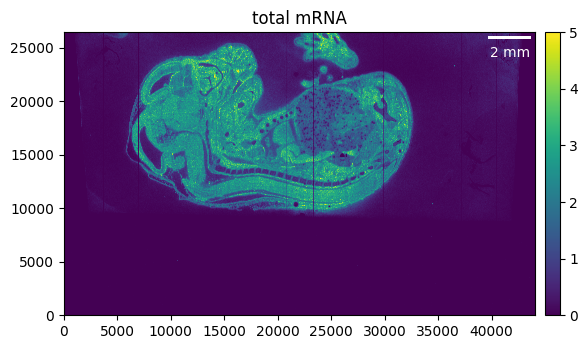

In [3]:
embryo.calculate_total_mRNA()

_ = embryo.plot_genecount(im_kwargs={"vmax": 5})

We can see that the region of interest in our case is much smaller than the total area of our sample. Cropping and masking help to focus only on the relevant parts of our tissue and, on top of that, will reduce memory usage and processing time.

For details, please refer to the {doc}`region-of-interest selection tutorial <roi>`.

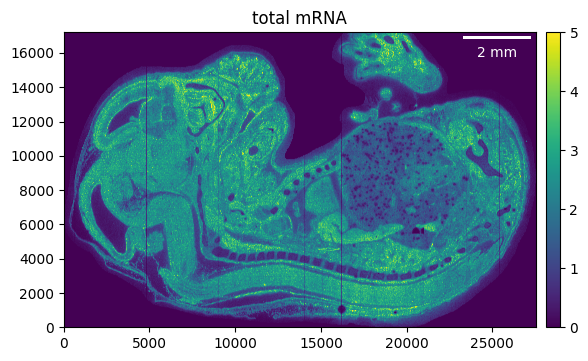

In [4]:
from PIL import Image

from sainsc.datasets import fetch_embryo_mask

# Avoid the DecompressionBombError
Image.MAX_IMAGE_PIXELS = None

# Crop approximate region of interest
embryo.counts.crop((5_000, 33_000), (9_000, None))

# Mask the embryo
mask_file = fetch_embryo_mask()
embryo_mask = np.array(Image.open(mask_file), dtype=bool)

embryo.counts.filter_mask(embryo_mask)

# Drop genes without counts after ROI selection
embryo.counts.filter_genes_by_count(1)

# Visualize
embryo.calculate_total_mRNA()

_ = embryo.plot_genecount(im_kwargs={"vmax": 5})

We can visualize the number of counts per gene as a histogram to get a quick overview of the distribution.

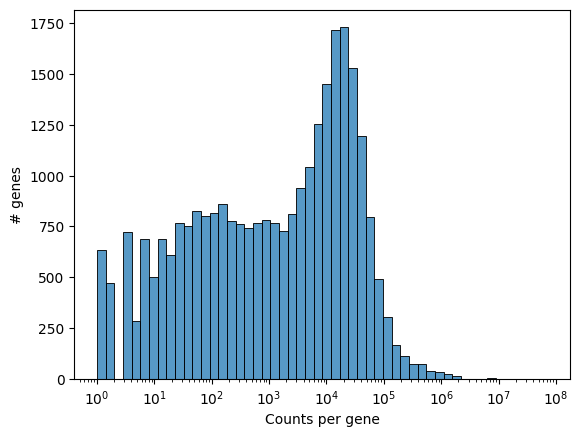

In [5]:
_ = embryo.plot_genecount_histogram()

Additional functionality like filtering the genes by counts or selecting them by name is available for [`sainsc.GridCounts`](#sainsc.GridCounts).

## Kernel density estimation (KDE)

To estimate the kernel density, we first need to define a kernel. This can easily be done using the [`sainsc.LazyKDE.gaussian_kernel`](#sainsc.LazyKDE.gaussian_kernel) method, allowing us to either specify the bandwidth in pixels or um.
Generally, we found ~4 um to work for most samples.

Except for the total mRNA, the KDE is not stored but rather calculated whenever it is needed (e.g., for plotting or assigning cell types).

In [6]:
embryo.gaussian_kernel(4, unit="um")

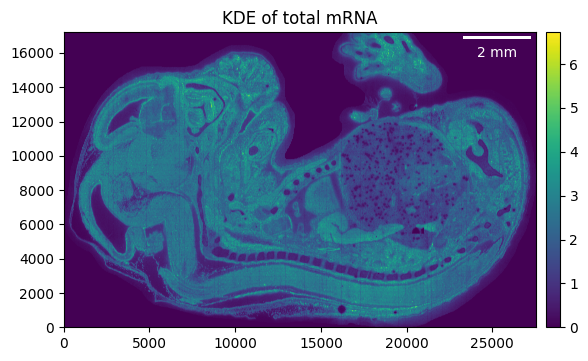

In [7]:
embryo.calculate_total_mRNA_KDE()

_ = embryo.plot_KDE()

### Filtering background

The histogram of the total mRNA KDE can be useful to define which areas are likely to be background (i.e., 'empty' or noisy areas).

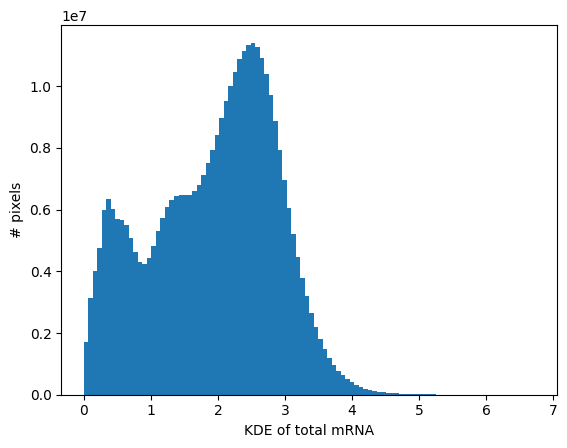

In [8]:
_ = embryo.plot_KDE_histogram(bins=100)

Here, we will use a rough estimate of 0.9, but will later make use of the fact that we can also filter the background with a threshold per cell type.

Background will not be removed, so data will not be overwritten to avoid recomputation.
Rather, corresponding values are set to 0 when plotting or similar.

In [9]:
embryo.filter_background(0.9)

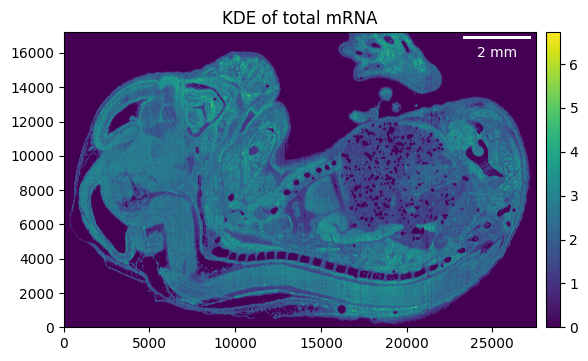

In [10]:
_ = embryo.plot_KDE(remove_background=True)

## Cell-type assignment

All we need to assign a cell type to every pixel in our sample is a previously defined kernel and a set of gene expression signatures.

The gene expression signatures can be based on prior knowledge (e.g., scRNA-seq experiments) or computed *de novo*, as we will demonstrate later.

Importantly, the cell-type signatures are expected to be non-negative.
So transformations to the reference data, such as library-size normalization or log-transformation, are suitable.
However, the cell-type signatures should not be calculated from, e.g., z-scores or Pearson residuals.
If you log-transform your reference data before signature calculation, you should also consider this when assigning the cell types with the [`sainsc.LazyKDE.assign_celltype`](#sainsc.LazyKDE.assign_celltype) method using the `log` argument.

### Annotation via label transfer from known signatures

Here, our signatures are pre-computed already and based on the segmented data published in the original Stereo-seq publication by [Chen *et al.* 2022](https://doi.org/10.1016/j.cell.2022.04.003) using the [`sainsc.utils.celltype_signatures`](#sainsc.utils.celltype_signatures) function.

In [11]:
from sainsc.datasets import fetch_embryo_signatures

signatures = fetch_embryo_signatures()
signatures.iloc[:, :4].head()

,Cardiomyocyte,Chondrocyte,Choroid plexus,Dorsal midbrain neuron
gene,,,,
1110017D15Rik,0.000022,0.000039,0.001147,0.000077
1110035H17Rik,0.000003,0.000002,0.000000,0.000010
1190001M18Rik,0.000002,0.000003,0.000000,0.000005
1300014J16Rik,0.000003,0.000005,0.000000,0.000004
1500015O10Rik,0.000069,0.000884,0.003061,0.000075


Now, we can assign the cell type.
This is usually the most computationally expensive step.

In [12]:
embryo.assign_celltype(signatures)

print(embryo)

LazyKDE (16 threads)
    genes: 28558
    shape: (27520, 17204)
    resolution: 500.0 nm / px
    kernel: (33, 33)
    background: set
    celltypes: 25


Visualizing the cell-type map is straightforward.
You can use a custom color mapping for the cell types as well.

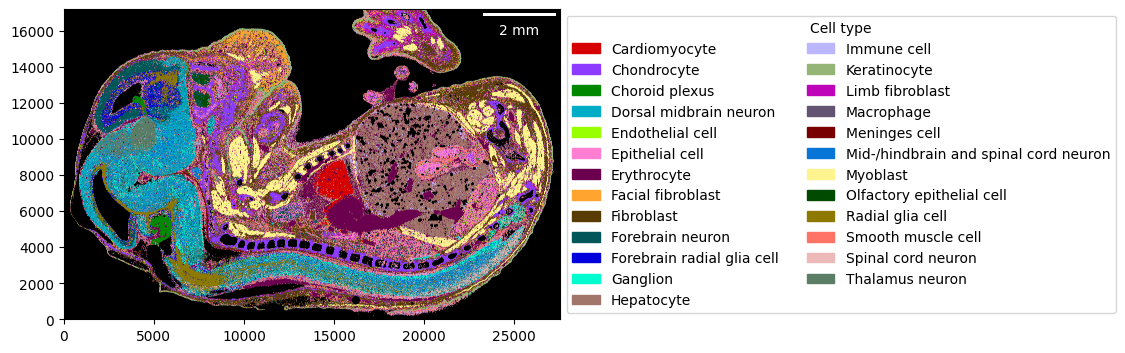

In [13]:
import colorcet as cc

cmap = dict(zip(embryo.celltypes, cc.glasbey))

_ = embryo.plot_celltype_map(cmap=cmap)

The assignment score helps identify regions that have been assigned with high confidence vs regions with low confidence.
Please refer to the `sainsc` publication for details.

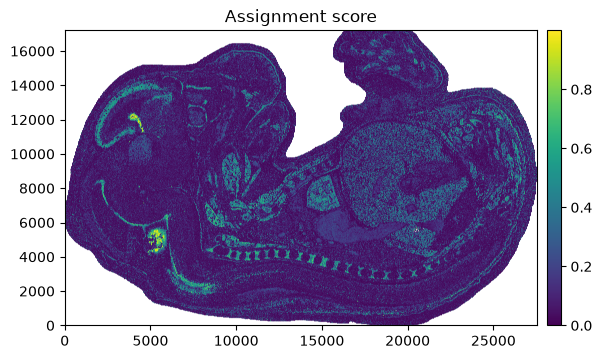

In [14]:
_ = embryo.plot_assignment_score()

In [15]:
# save analysis for later notebooks
import pickle

with open("embryo.pickle", "wb") as file:
    pickle.dump(embryo, file)

### *De novo* cell-type signatures

To generate a cell-type map without prior knowledge of the cell types or their expression profiles, we can use expression signatures that we generate from the data directly.

Briefly, we identify local maxima of the gene expression as proxies for cells. We load the KDE of these cell proxies and use it to cluster the data following standard single-cell RNA sequencing workflows. Using the expression of the extracted clusters, we can generate the cell-type map.

First off, we need to identify the local maxima. We only need to specify the minimum distance between two maxima, but it can be helpful to filter the background and only identify maxima in connected regions of a minimum size.

In [16]:
embryo.find_local_maxima(4, min_area=60)

print(embryo)

LazyKDE (16 threads)
    genes: 28558
    shape: (27520, 17204)
    resolution: 500.0 nm / px
    kernel: (33, 33)
    background: set
    local maxima: 171503
    celltypes: 25


Relevant genes can be found either;

- through prior knowledge from e.g. literature
- by loading the data in bins using [`sainsc.io.read_StereoSeq_bins`](#sainsc.io.read_StereoSeq_bins) and then identifying highly-variable (HVG) or spatially-variable genes (SVG)
- loading (all) genes for the local maxima and detecting HVGs/SVGs based on their expression

Here, we will follow the last approach. We load the local maxima as [`AnnData`](#anndata.AnnData), though we will only keep genes with more than 100 and fewer than 100,000 transcripts.

In [17]:
counts_per_gene = embryo.counts.gene_counts()
load_genes = [g for g, c in counts_per_gene.items() if 100 < c < 10**5]

In [18]:
cellproxy_adata = embryo.load_local_maxima(load_genes)

print(cellproxy_adata)

AnnData object with n_obs × n_vars = 171503 × 19796
    obs: 'total_mRNA_KDE', 'cosine_similarity', 'assignment_score', 'celltype'
    obsm: 'spatial'


... and process it using a standard `scanpy`/`squidpy` workflow.

In [19]:
import scanpy as sc

# "normalize" data
sc.pp.normalize_total(cellproxy_adata)
sc.pp.log1p(cellproxy_adata)

In [20]:
import squidpy as sq

# random seed for reproducibility
seed = 42

# find SVGs
sq.gr.spatial_neighbors(cellproxy_adata, coord_type="generic")
sq.gr.spatial_autocorr(cellproxy_adata, mode="moran", seed=seed)

svg = cellproxy_adata.uns["moranI"]["I"].dropna().nlargest(2_000).index

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


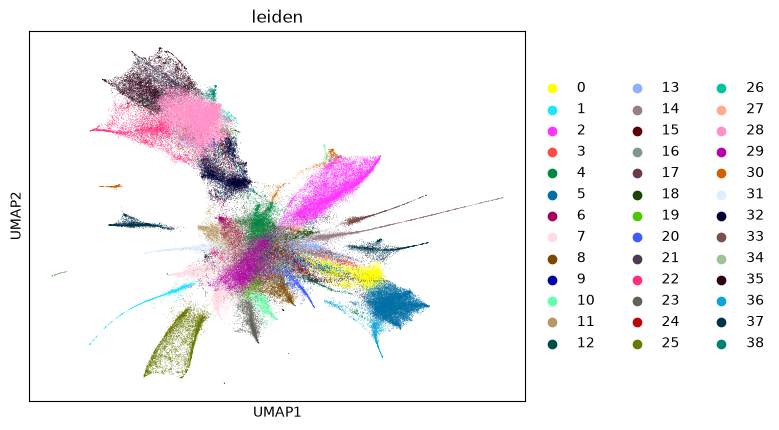

In [21]:
# find cell-type clusters
sc.pp.pca(
    cellproxy_adata, mask_var=cellproxy_adata.var_names.isin(svg), random_state=seed
)
sc.pp.neighbors(cellproxy_adata, random_state=seed)
sc.tl.umap(cellproxy_adata, min_dist=0.1, random_state=seed)
sc.tl.leiden(cellproxy_adata, resolution=1, flavor="igraph", random_state=seed)

sc.pl.umap(cellproxy_adata, color="leiden")

Once we have identified our cell-type clusters, we can extract the cell-type signatures and proceed as previously.
Of course, the cell-type clusters can further be annotated by looking at marker genes and assigning actual cell types using standard single-cell workflows.
Scanpy provides excellent [tutorials](https://scanpy.scverse.org/page/tutorials/basics/clustering.html) for this. 

In [ ]:
from sainsc.utils import celltype_signatures

signatures_denovo = celltype_signatures(cellproxy_adata[:, svg], celltype_col="leiden")

embryo.assign_celltype(signatures_denovo, log=True)

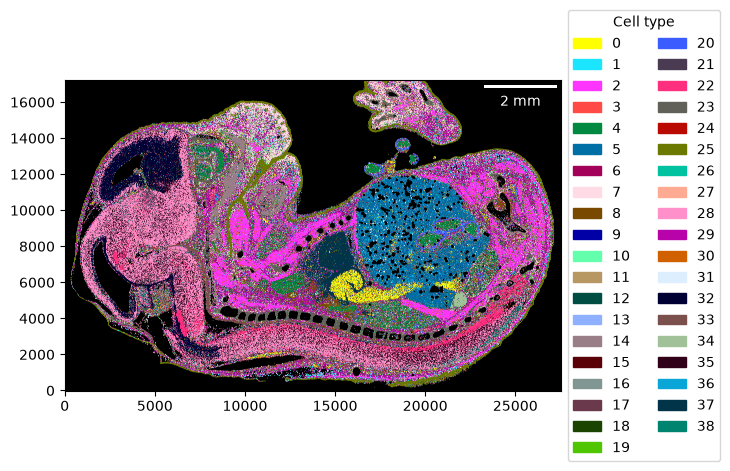

In [27]:
# use same colors as in UMAP
cmap_denovo = dict(
    zip(
        cellproxy_adata.obs["leiden"].cat.categories,
        cellproxy_adata.uns["leiden_colors"],
    )
)

_ = embryo.plot_celltype_map(cmap=cmap_denovo)

## Cell-type-specific thresholds

Background filtering supports cell type-specific thresholding; this can be useful as the total mRNA in some cell types might be higher (especially when working with smaller gene panels such as those from Xenium data).

In [34]:
kde_per_celltype = pd.DataFrame(
    {
        "kde": embryo.total_mRNA_KDE.flatten(),
        "celltype": pd.Categorical.from_codes(
            embryo.celltype_map.ravel(), categories=embryo.celltypes
        ),
    }
).dropna()

celltype_threshold = (
    kde_per_celltype.groupby("celltype", observed=True).median()["kde"] / 2
).to_dict()

min_t = 0.9

celltype_threshold = {
    ct: (t if t > min_t else min_t) for ct, t in celltype_threshold.items()
}

embryo.filter_background(celltype_threshold)

For example, we can see that some background around the choroid plexus is removed.

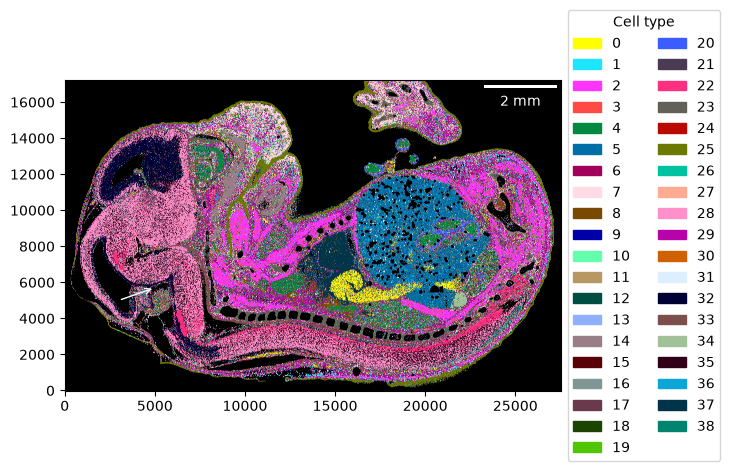

In [42]:
fig = embryo.plot_celltype_map(cmap=cmap_denovo)

# draw arrow
_ = fig.axes[0].annotate(
    "",
    xytext=(3_000, 5_000),
    xy=(5_000, 5_700),
    arrowprops=dict(arrowstyle="->", color="white"),
)